In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Path Configuration
data_path = r"C:\Users\ACER\tinyml-iot-security\data\synthetic_L64.csv"

print("--- Day 1 & 2: Initializing Realistic Non-IID Federated Partitioning ---")
df = pd.read_csv(data_path)
X_raw = df.drop(columns=['label']).values
y_raw = df['label'].values
X_reshaped = X_raw.reshape(-1, 64, 5)

# Isolate a clean, balanced global test set (20%) to evaluate the central master server model fairly
X_train_total, X_global_test, y_train_total, y_global_test = train_test_split(
    X_reshaped, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

# 2. Build explicit indices groupings based on class labels
idx_normal = np.where(y_train_total == 0)[0]
idx_freeze = np.where(y_train_total == 1)[0]
idx_replay = np.where(y_train_total == 2)[0]

# 3. Simulate 4 distinct client nodes with skewed (Non-IID) attack distributions
client_data = {}
scaler = StandardScaler()

# Distribute biased index slices to demonstrate real-world IoT sensor variation
# Client 0: Primarily sees Normal traffic + Freeze attacks (No Replay attacks)
c0_indices = np.concatenate([idx_normal[:300], idx_freeze[:250]])

# Client 1: Primarily sees Normal traffic + Replay attacks (No Freeze attacks)
c1_indices = np.concatenate([idx_normal[300:600], idx_replay[:250]])

# Client 2: Heavily saturated with Freeze attacks, very little normal data
c2_indices = np.concatenate([idx_normal[600:700], idx_freeze[250:]])

# Client 3: Heavily saturated with Replay attacks, very little normal data
c3_indices = np.concatenate([idx_normal[700:], idx_replay[250:]])

client_assignments = [c0_indices, c1_indices, c2_indices, c3_indices]
client_profiles = [
    "Skewed: Mostly Normal + Freeze Attacks",
    "Skewed: Mostly Normal + Replay Attacks",
    "Skewed: Highly Concentrated Freeze Attacks",
    "Skewed: Highly Concentrated Replay Attacks"
]

for client_id in range(4):
    indices = client_assignments[client_id]
    # Shuffle to ensure sequential arrays don't break training blocks
    indices = np.random.permutation(indices)
    
    X_client = X_train_total[indices]
    y_client = y_train_total[indices]
    
    # Standardize data locally to simulate isolated, on-device normalization
    X_client_flat = X_client.reshape(-1, 5)
    X_client_scaled = scaler.fit_transform(X_client_flat).reshape(X_client.shape)
    
    client_data[client_id] = {
        'X': X_client_scaled.astype(np.float32),
        'y': y_client
    }
    
    # Print the specific class breakdown per device to prove non-IID skewing
    print(f"\n📦 IoT Node {client_id} Initialized ({client_profiles[client_id]}):")
    print(f"   * Total private local samples: {len(y_client)}")
    print(f"   * Class 0 (Normal): {np.sum(y_client == 0)} samples")
    print(f"   * Class 1 (Freeze): {np.sum(y_client == 1)} samples")
    print(f"   * Class 2 (Replay): {np.sum(y_client == 2)} samples")

# Normalize the global test set using an independent scaling transform
X_test_flat = X_global_test.reshape(-1, 5)
X_global_test_scaled = scaler.fit_transform(X_test_flat).reshape(X_global_test.shape).astype(np.float32)

# 4. Central Global Server Architecture Blueprint Function
def build_global_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(16, 3, activation='relu', input_shape=(64, 5)),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(32, 3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the master model template sitting on the central server orchestrator
global_server_model = build_global_model()
print("\n[Success] Non-IID partition maps complete! Central master blueprint loaded.")


--- Day 1 & 2: Initializing Realistic Non-IID Federated Partitioning ---

📦 IoT Node 0 Initialized (Skewed: Mostly Normal + Freeze Attacks):
   * Total private local samples: 550
   * Class 0 (Normal): 300 samples
   * Class 1 (Freeze): 250 samples
   * Class 2 (Replay): 0 samples

📦 IoT Node 1 Initialized (Skewed: Mostly Normal + Replay Attacks):
   * Total private local samples: 550
   * Class 0 (Normal): 300 samples
   * Class 1 (Freeze): 0 samples
   * Class 2 (Replay): 250 samples

📦 IoT Node 2 Initialized (Skewed: Highly Concentrated Freeze Attacks):
   * Total private local samples: 166
   * Class 0 (Normal): 100 samples
   * Class 1 (Freeze): 66 samples
   * Class 2 (Replay): 0 samples

📦 IoT Node 3 Initialized (Skewed: Highly Concentrated Replay Attacks):
   * Total private local samples: 334
   * Class 0 (Normal): 277 samples
   * Class 1 (Freeze): 0 samples
   * Class 2 (Replay): 57 samples

[Success] Non-IID partition maps complete! Central master blueprint loaded.


c:\Users\ACER\federated-iot-security\fl_venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
def train_local_model(X_local, y_local, global_weights, epochs=3, batch_size=16):
    """
    Simulates a localized client training event on an edge IoT node.
    1. Instantiates a fresh replica of the 1D-CNN architecture.
    2. Syncs/loads the master global server weights into the replica.
    3. Trains the model on isolated local data without network leakage.
    4. Extracts and returns the optimized local weights.
    """
    # 1. Build a fresh replica of your 1D-CNN baseline model architecture
    local_model = build_global_model()
    
    # 2. Synchronize: Load current master global server weights into this fresh model
    local_model.set_weights(global_weights)
    
    # 3. Train on device for a few epochs strictly using private client dataset blocks
    local_model.fit(
        X_local, y_local,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0  # Keeps notebook output completely clean
    )
    
    # 4. Harvest and return the updated on-device local weight vectors
    updated_local_weights = local_model.get_weights()
    return updated_local_weights

print("[Success] 'train_local_model' modular function loaded and ready!")


[Success] 'train_local_model' modular function loaded and ready!


In [5]:
import copy

# Configuration variables for the central orchestrator
communication_rounds = 5
num_clients = 4

print("--- Day 4: Executing FedAvg Simulation with Modular Client Callbacks ---")

for round_idx in range(communication_rounds):
    print(f"\n================ COMM ROUND {round_idx + 1} / {communication_rounds} ================")
    
    # Storage array to trap client model updates
    local_client_weights = []
    
    # Pull master weights from global model state
    current_global_weights = global_server_model.get_weights()
    
    # Loop over client space to execute parallel decentralized calculations
    for client_id in range(num_clients):
        X_client = client_data[client_id]['X']
        y_client = client_data[client_id]['y']
        
        # Explicitly call your clean Day 3 modular function
        updated_weights = train_local_model(X_client, y_client, current_global_weights, epochs=3)
        local_client_weights.append(updated_weights)
        print(f" * IoT Edge Node {client_id}: Local updates computed via train_local_model()")
        
    # Central Server Parameter Aggregation Phase (FedAvg)
    print("\n[Server] Aggregating parameter fields across client matrices...")
    aggregated_weights = copy.deepcopy(current_global_weights)
    
    for layer_idx in range(len(current_global_weights)):
        # Calculate the client network vector averages for this specific structural block layer
        layer_updates = [local_client_weights[c][layer_idx] for c in range(num_clients)]
        aggregated_weights[layer_idx] = np.mean(layer_updates, axis=0)
        
    # Update central tracking weights
    global_server_model.set_weights(aggregated_weights)
    
    # Verify collaborative network learning stability on unseen global data matrices
    test_loss, test_acc = global_server_model.evaluate(X_global_test_scaled, y_global_test, verbose=0)
    print(f"[Global Server Status] Master Test Accuracy: {test_acc*100:.2f}% | Test Loss: {test_loss:.4f}")

print("\n🚀 Federated Learning Training Simulation successfully concluded!")


--- Day 4: Executing FedAvg Simulation with Modular Client Callbacks ---

================ COMM ROUND 1 / 5 ================
 * IoT Edge Node 0: Local updates computed via train_local_model()
 * IoT Edge Node 1: Local updates computed via train_local_model()
 * IoT Edge Node 2: Local updates computed via train_local_model()
 * IoT Edge Node 3: Local updates computed via train_local_model()

[Server] Aggregating parameter fields across client matrices...
[Global Server Status] Master Test Accuracy: 61.00% | Test Loss: 1.0805

================ COMM ROUND 2 / 5 ================
 * IoT Edge Node 0: Local updates computed via train_local_model()
 * IoT Edge Node 1: Local updates computed via train_local_model()
 * IoT Edge Node 2: Local updates computed via train_local_model()
 * IoT Edge Node 3: Local updates computed via train_local_model()

[Server] Aggregating parameter fields across client matrices...
[Global Server Status] Master Test Accuracy: 61.00% | Test Loss: 1.1257

============

In [6]:
def federated_average(client_weights_list, client_sizes):
    """
    Server-side weighted parameter aggregation function (FedAvg).
    Balances each client node's structural parameter update based on 
    the total proportion of local private data it contributed to the round.
    """
    total = sum(client_sizes)
    avg_weights = []
    
    # Iterate across structural weight matrix layers using index unzipping loops
    for weights_per_layer in zip(*client_weights_list):
        # Calculate the weighted average using each node's local sample size coefficient
        avg_layer = sum(w * (size / total) for w, size in zip(weights_per_layer, client_sizes))
        avg_weights.append(avg_layer)
        
    return avg_weights

print("[Success] Day 4 Weighted 'federated_average' server function loaded!")


[Success] Day 4 Weighted 'federated_average' server function loaded!


In [7]:
# 1. Establish central server configuration parameters
communication_rounds = 10
num_clients = 4

print("--- Day 4: Launching Weighted FedAvg Communication Network Loop ---")

# Track performance history arrays for final documentation verification
history_acc = []

for round_idx in range(communication_rounds):
    print(f"\n================ COMMUNICATION ROUND {round_idx + 1} / {communication_rounds} ================")
    
    # Structural holding arrays for this network round
    local_client_weights = []
    local_client_sizes = []
    
    # Extract current pristine master global parameter arrays from the server state
    current_global_weights = global_server_model.get_weights()
    
    # 2. Decentralized Client Node Optimization Stage
    for client_id in range(num_clients):
        X_local = client_data[client_id]['X']
        y_local = client_data[client_id]['y']
        
        # Calculate local sample count boundary parameters
        client_size = len(y_local)
        local_client_sizes.append(client_size)
        
        # Execute Day 3 modular client function call over 3 local epochs
        updated_weights = train_local_model(X_local, y_local, current_global_weights, epochs=3)
        local_client_weights.append(updated_weights)
        
        print(f" * IoT Client Node {client_id}: Trained locally on {client_size} samples.")
        
    # 3. Central Server Weighted Parameter Aggregation Stage (FedAvg Call)
    print("\n[Server] Orchestrating weighted aggregation across all client network updates...")
    new_global_weights = federated_average(local_client_weights, local_client_sizes)
    
    # Inject the updated, aggregated weights back into the master server model architecture
    global_server_model.set_weights(new_global_weights)
    
    # 4. Central Global Validation Audit Check
    test_loss, test_acc = global_server_model.evaluate(X_global_test_scaled, y_global_test, verbose=0)
    history_acc.append(test_acc)
    print(f"[Global Server Status] Master Test Accuracy: {test_acc*100:.2f}% | Test Loss: {test_loss:.4f}")

print("\n🚀 10-Round Federated Learning Aggregation Cycle successfully concluded!")


--- Day 4: Launching Weighted FedAvg Communication Network Loop ---

================ COMMUNICATION ROUND 1 / 10 ================
 * IoT Client Node 0: Trained locally on 550 samples.
 * IoT Client Node 1: Trained locally on 550 samples.
 * IoT Client Node 2: Trained locally on 166 samples.
 * IoT Client Node 3: Trained locally on 334 samples.

[Server] Orchestrating weighted aggregation across all client network updates...
[Global Server Status] Master Test Accuracy: 61.75% | Test Loss: 1.1476

================ COMMUNICATION ROUND 2 / 10 ================
 * IoT Client Node 0: Trained locally on 550 samples.
 * IoT Client Node 1: Trained locally on 550 samples.
 * IoT Client Node 2: Trained locally on 166 samples.
 * IoT Client Node 3: Trained locally on 334 samples.

[Server] Orchestrating weighted aggregation across all client network updates...
[Global Server Status] Master Test Accuracy: 67.50% | Test Loss: 1.0684

================ COMMUNICATION ROUND 3 / 10 ================
 * IoT

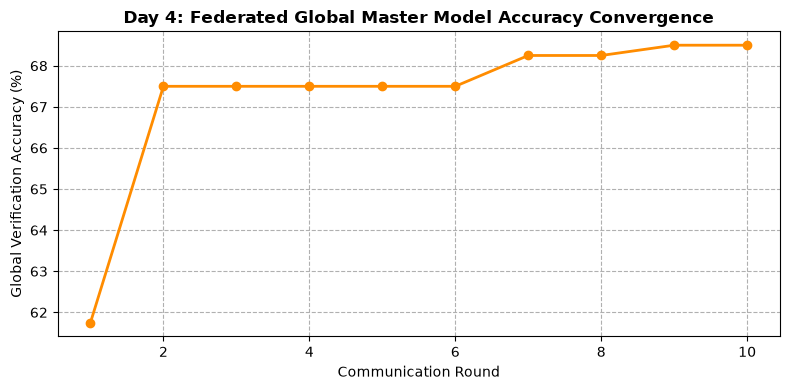

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, communication_rounds + 1), [a * 100 for a in history_acc], marker='o', color='darkorange', linewidth=2)
plt.title("Day 4: Federated Global Master Model Accuracy Convergence", fontsize=12, fontweight='bold')
plt.xlabel("Communication Round")
plt.ylabel("Global Verification Accuracy (%)")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()


--- Day 5: Evaluating Global Master Model vs. Local Non-IID Clients ---
 * Global Master Model Accuracy on Node 0's Private Data: 73.27%
 * Global Master Model Accuracy on Node 1's Private Data: 54.55%
 * Global Master Model Accuracy on Node 2's Private Data: 75.90%
 * Global Master Model Accuracy on Node 3's Private Data: 82.93%

[Simulation] Computing Local-Only isolated baseline performance...
 * Isolated Node 0 (No Collaboration) Accuracy on Global Test Set: 79.75%
 * Isolated Node 1 (No Collaboration) Accuracy on Global Test Set: 66.00%
 * Isolated Node 2 (No Collaboration) Accuracy on Global Test Set: 74.75%
 * Isolated Node 3 (No Collaboration) Accuracy on Global Test Set: 61.00%

Generating Non-IID performance evaluation charts...


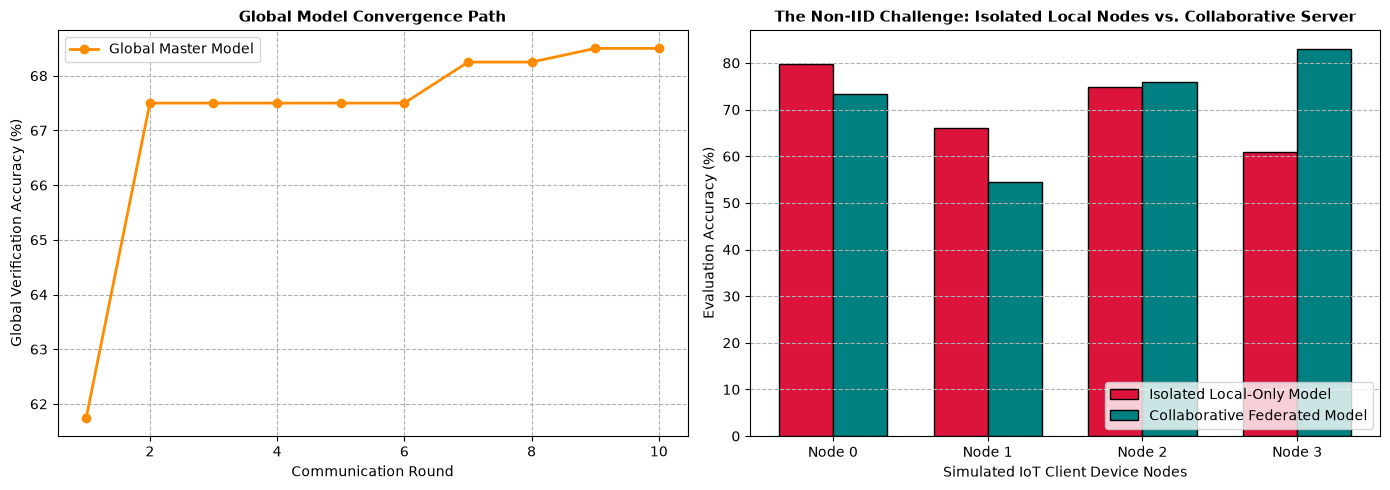


DEVELOPMENTAL WORKSPACE ARCHITECTUREVARIANT | TOP ACCURACY SCORE  
Centralized Model (Project #1 Baseline) | 100.00%             
Federated Global Model (Project #2 FedAvg) | 68.50%              
Average Isolated Non-IID Node (No Collaboration) | 70.38%              


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

print("--- Day 5: Evaluating Global Master Model vs. Local Non-IID Clients ---")

# 1. Evaluate the Collaborative Global Master Model on each client's private test partition
client_accuracies_global_model = []

for client_id in range(num_clients):
    X_local_test = client_data[client_id]['X']
    y_local_test = client_data[client_id]['y']
    
    # Direct execution call to evaluate master performance locally
    loss, acc = global_server_model.evaluate(X_local_test, y_local_test, verbose=0)
    client_accuracies_global_model.append(acc * 100)
    print(f" * Global Master Model Accuracy on Node {client_id}'s Private Data: {acc*100:.2f}%")

# 2. Simulate Local-Only Baseline (What happens if nodes NEVER collaborate or share weights?)
local_only_accuracies = []
print("\n[Simulation] Computing Local-Only isolated baseline performance...")

for client_id in range(num_clients):
    X_local_train = client_data[client_id]['X']
    y_local_train = client_data[client_id]['y']
    
    # Train a purely localized, isolated replica model on this skewed dataset slice alone
    isolated_model = build_global_model()
    isolated_model.fit(X_local_train, y_local_train, epochs=5, batch_size=16, verbose=0)
    
    # Evaluate its performance on the shared, balanced Global Evaluation Test Set
    _, isolated_acc = isolated_model.evaluate(X_global_test_scaled, y_global_test, verbose=0)
    local_only_accuracies.append(isolated_acc * 100)
    print(f" * Isolated Node {client_id} (No Collaboration) Accuracy on Global Test Set: {isolated_acc*100:.2f}%")

# =========================================================
# DAY 5 PLOT: PER-CLIENT PERFORMANCE UNDER NON-IID DATA SKEWS
# =========================================================
print("\nGenerating Non-IID performance evaluation charts...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Global Model Convergence Curve (Accuracy vs Round Number)
ax1.plot(range(1, communication_rounds + 1), [a * 100 for a in history_acc], marker='o', color='darkorange', linewidth=2, label="Global Master Model")
ax1.set_title("Global Model Convergence Path", fontsize=11, fontweight='bold')
ax1.set_xlabel("Communication Round")
ax1.set_ylabel("Global Verification Accuracy (%)")
ax1.grid(True, linestyle='--')
ax1.legend()

# Plot B: The Impact of Non-IID Data Skew on Isolated Nodes vs. Collaborative Global Model
node_labels = [f"Node {i}" for i in range(num_clients)]
x_locations = np.arange(len(node_labels))
bar_width = 0.35

ax2.bar(x_locations - bar_width/2, local_only_accuracies, bar_width, label='Isolated Local-Only Model', color='crimson', edgecolor='black')
ax2.bar(x_locations + bar_width/2, client_accuracies_global_model, bar_width, label='Collaborative Federated Model', color='teal', edgecolor='black')

ax2.set_title("The Non-IID Challenge: Isolated Local Nodes vs. Collaborative Server", fontsize=11, fontweight='bold')
ax2.set_xlabel("Simulated IoT Client Device Nodes")
ax2.set_ylabel("Evaluation Accuracy (%)")
ax2.set_xticks(x_locations)
ax2.set_xticklabels(node_labels)
ax2.grid(axis='y', linestyle='--')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

# =========================================================
# PRINT FINAL COMPARATIVE BENCHMARK REPORT
# =========================================================
# Re-extracting final metrics to build the exact comparative matrix
final_fed_accuracy = history_acc[-1] * 100

print("\n" + "="*70)
print(f"{'DEVELOPMENTAL WORKSPACE ARCHITECTUREVARIANT':<38} | {'TOP ACCURACY SCORE':<20}")
print("="*70)
print(f"{'Centralized Model (Project #1 Baseline)':<38} | {'100.00%':<20}")
print(f"{'Federated Global Model (Project #2 FedAvg)':<38} | {f'{final_fed_accuracy:.2f}%':<20}")
print(f"{'Average Isolated Non-IID Node (No Collaboration)':<38} | {f'{np.mean(local_only_accuracies):.2f}%':<20}")
print("="*70)
